In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df_copy = pd.read_csv('datafiles/Training_set.csv',delimiter=",")

In [6]:
df = pd.read_csv('datafiles/Training_set.csv',delimiter=",")
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [7]:
df_labels = pd.read_csv('datafiles/Training_set_lables.csv',delimiter=",")
df_labels.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


In [8]:
df_labels['status_group'].value_counts(normalize=True)

status_group
functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: proportion, dtype: float64

<Axes: >

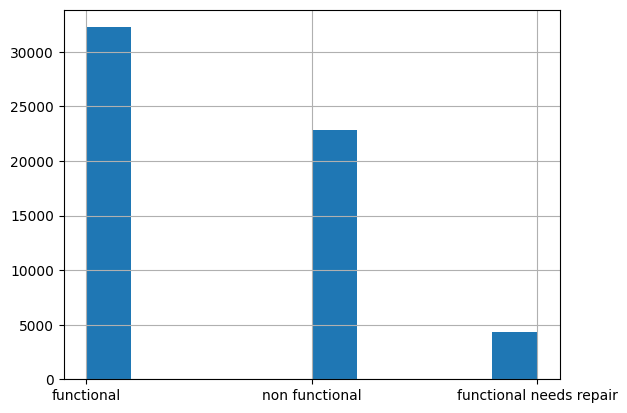

In [9]:
df_labels['status_group'].hist()

In [10]:
#Checking column data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

Data Observation
59400 rows and 39 columns are present in the  training dataset.
The population around the water pumps ranges from  0 to 30500.
Construction year has values as 0 and ranges from 1960 to 2013.
The training data contains many columns with identical values. These are classified and grouped into few values. For better data cleaning, these columns are deleted, allowing us to use higher-grouped columns with fewer values.
recorded_by column has one value repeated which can be dropped.
region_code and district_code are having "many to many" mapping


In [11]:
# Analyzing the Data distribution 

#print(df.describe())

df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [12]:
# Check for missing values


df.isnull().sum().sort_values(ascending=False).head(20)

scheme_name          28810
scheme_management     3878
installer             3655
funder                3637
public_meeting        3334
permit                3056
subvillage             371
wpt_name                 2
latitude                 0
longitude                0
gps_height               0
date_recorded            0
id                       0
amount_tsh               0
num_private              0
basin                    0
lga                      0
district_code            0
region_code              0
region                   0
dtype: int64

In [13]:
# Drop columns 

drop_cols = [c for c in ['recorded_by','id','num_private'] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Remaining NA counts:\n", df.isna().sum()[df.isna().sum()>0])

Remaining NA counts:
 funder                3637
installer             3655
wpt_name                 2
subvillage             371
public_meeting        3334
scheme_management     3878
scheme_name          28810
permit                3056
dtype: int64


In [14]:
train_data = pd.concat([df, df_labels.drop('id', axis=1)], axis=1)
train_data.head(2)

,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,basin,subvillage,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,Lake Nyasa,Mnyusi B,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,Lake Victoria,Nyamara,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


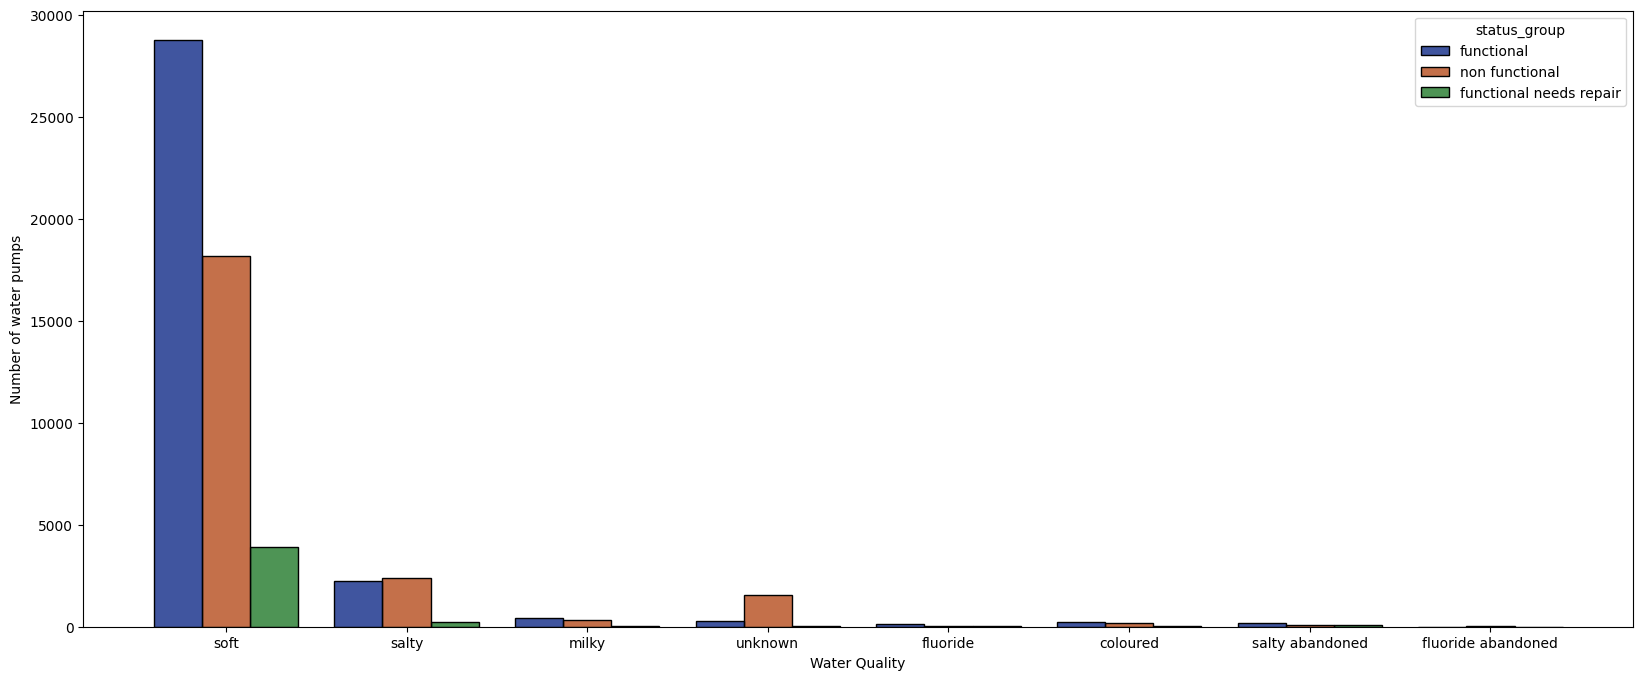

In [15]:
# Visualizing whether water quality has some effect on functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(20,8))
sns.histplot(data=train_data, x="water_quality", hue="status_group", multiple="dodge",palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("Water Quality")
ax.set_ylabel("Number of water pumps");

#Obseravtion
#Soft water has more functional pumps than non-functional
#Salty water results in more non-functional pumps 

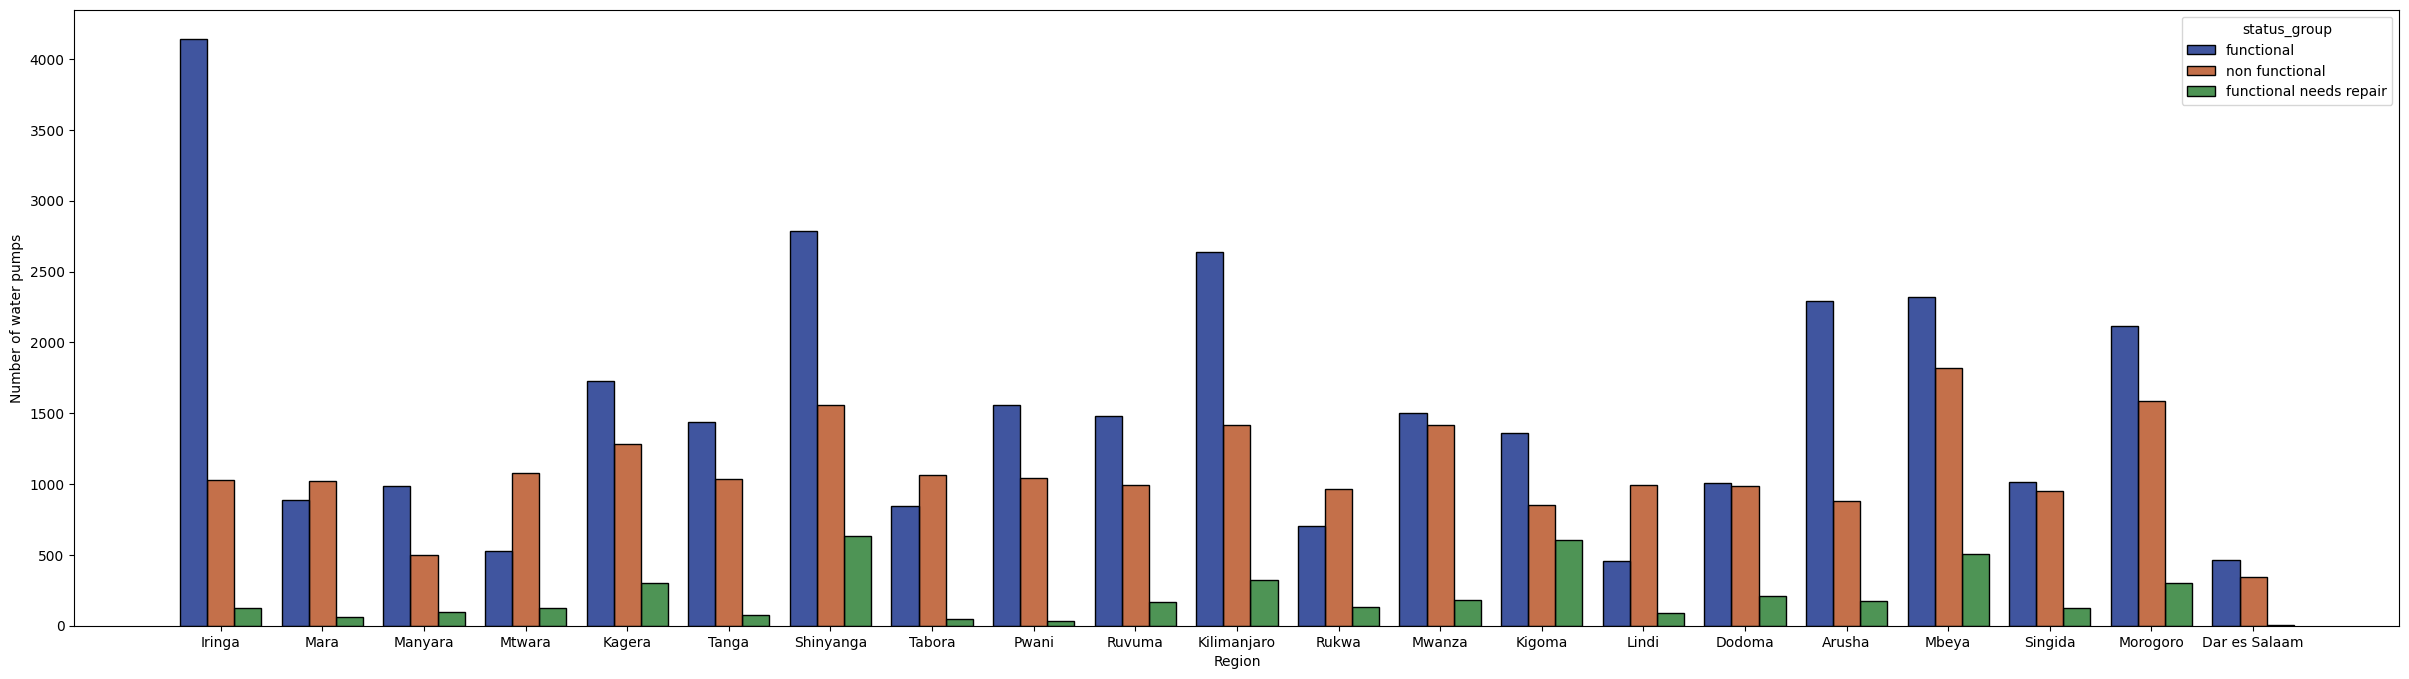

In [16]:
# Visualizing  Region wise functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(30,8))
sns.histplot(data=train_data, x="region", hue="status_group", multiple="dodge",palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("Region")
ax.set_ylabel("Number of water pumps");

#Observation
#Mbeye ,Morogoro and Shinyanga regions have more non-functional pumps.They need more attention.
#Iringa region is doing well as in case of more functional pumps

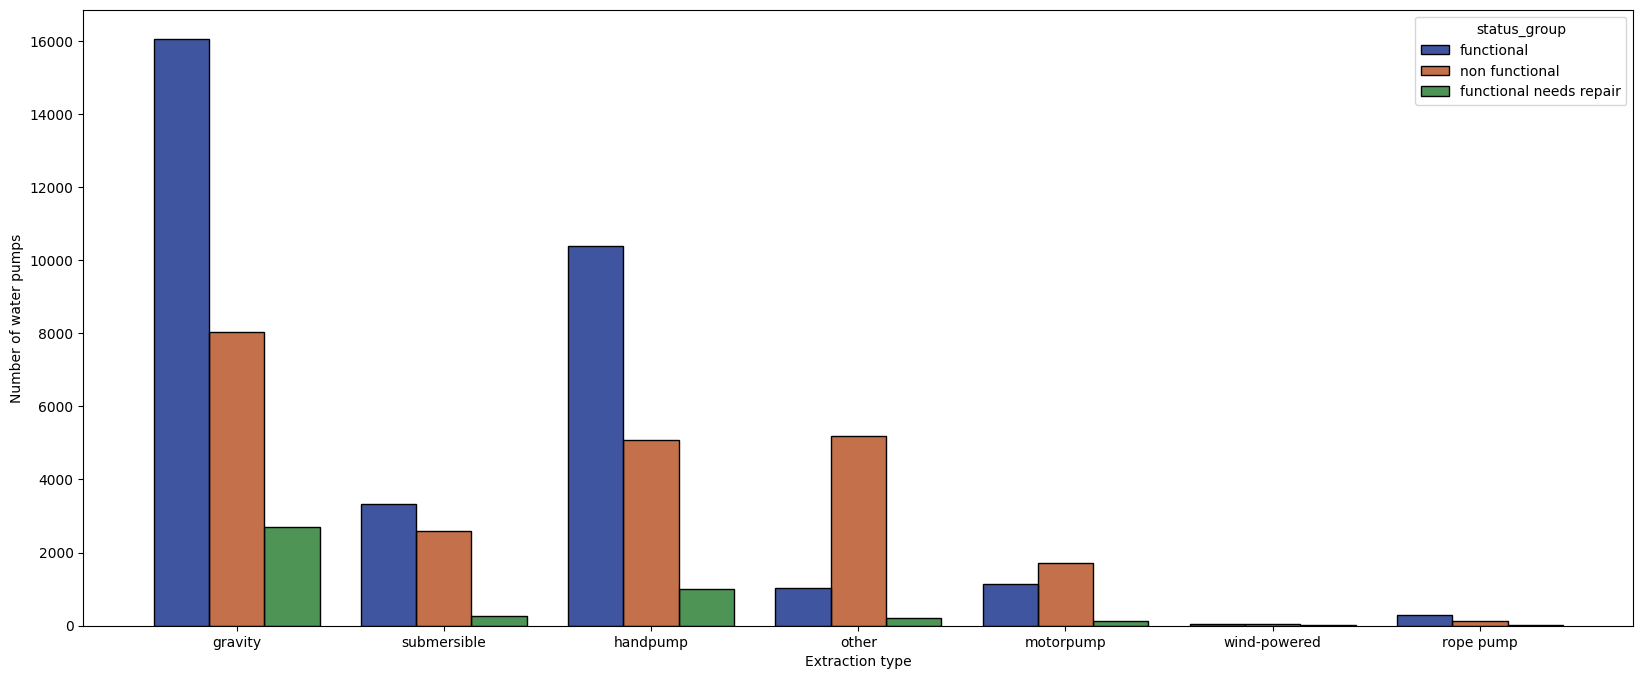

In [17]:
# Visualizing whether extraction type has some effect on functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(20,8))
sns.histplot(data=train_data, x="extraction_type_class", hue="status_group", multiple="dodge", palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("Extraction type")
ax.set_ylabel("Number of water pumps");

#Observation
#More non functional pumps are under Extraction type  "gravity" ,"handpump" and "other"

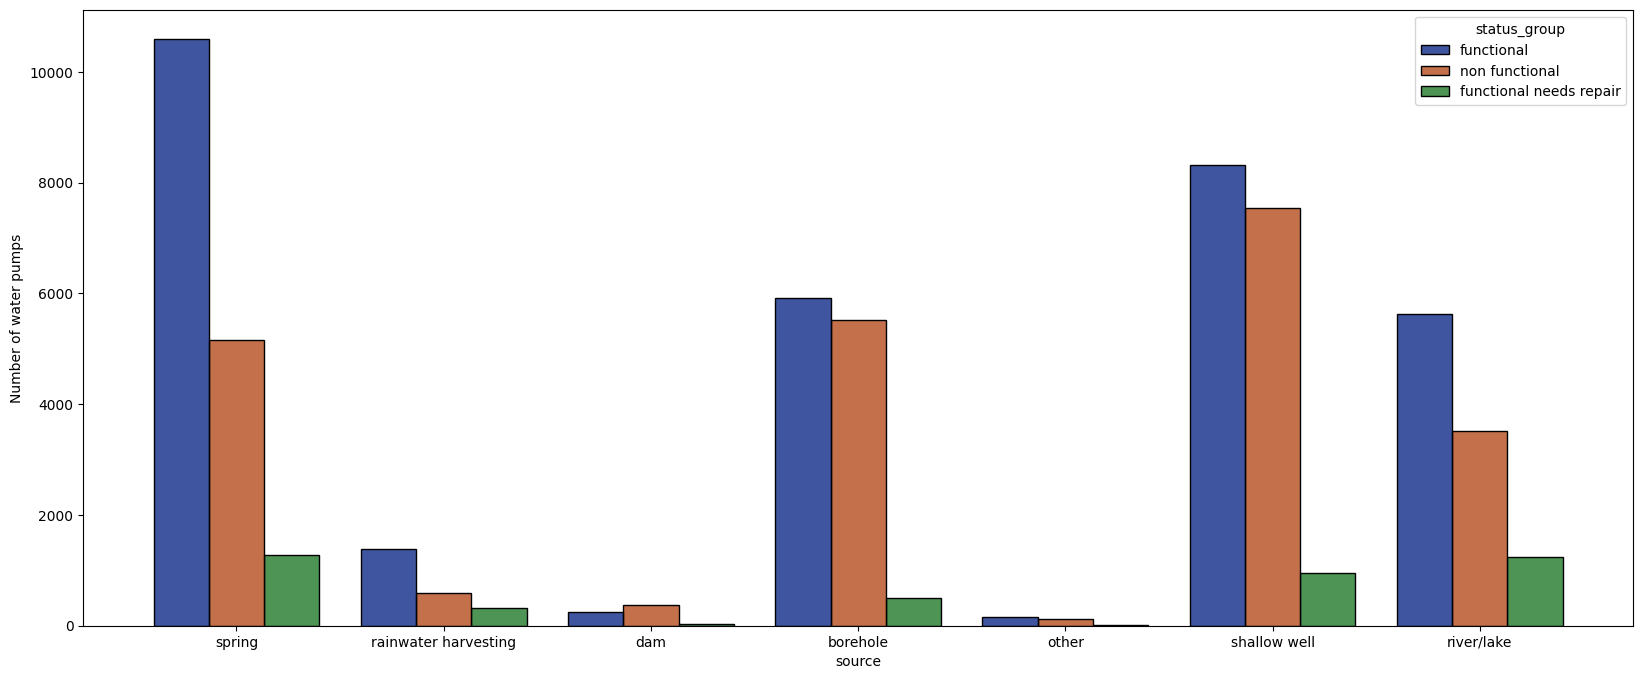

In [18]:
# Visualizing whether source of water has some effect on functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(20,8))
sns.histplot(data=train_data, x="source_type", hue="status_group", multiple="dodge",palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("source")
ax.set_ylabel("Number of water pumps");

#Observation
# Functional pipes are working well when having the Spring source
# Non-Functional pipes are more in shallow well source when compared to other sources

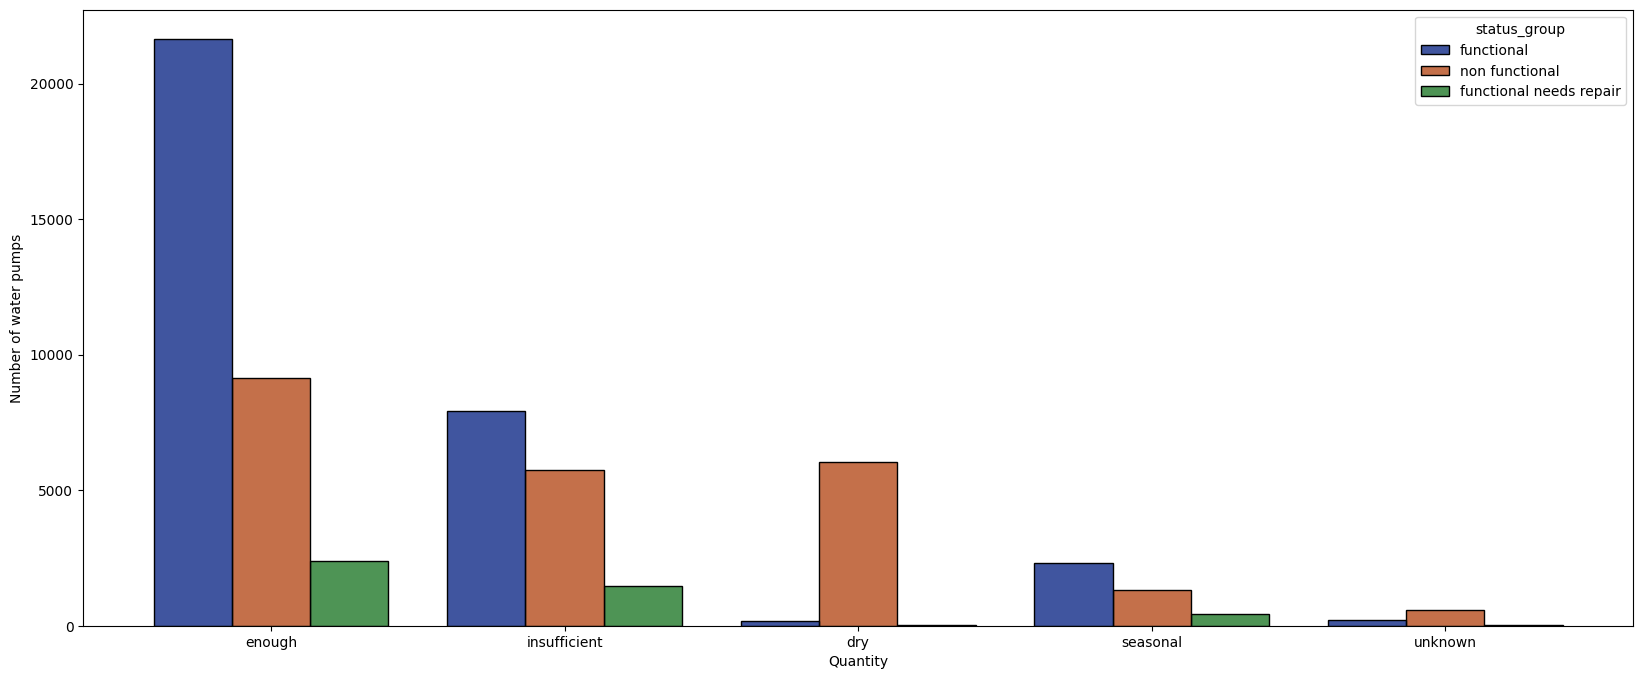

In [19]:
# Visualizing  Quantity of water  effect on functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(20,8))
sns.histplot(data=train_data, x="quantity_group", hue="status_group", multiple="dodge",palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("Quantity")
ax.set_ylabel("Number of water pumps");

#Observation
#Dry results in more non-functional pumps

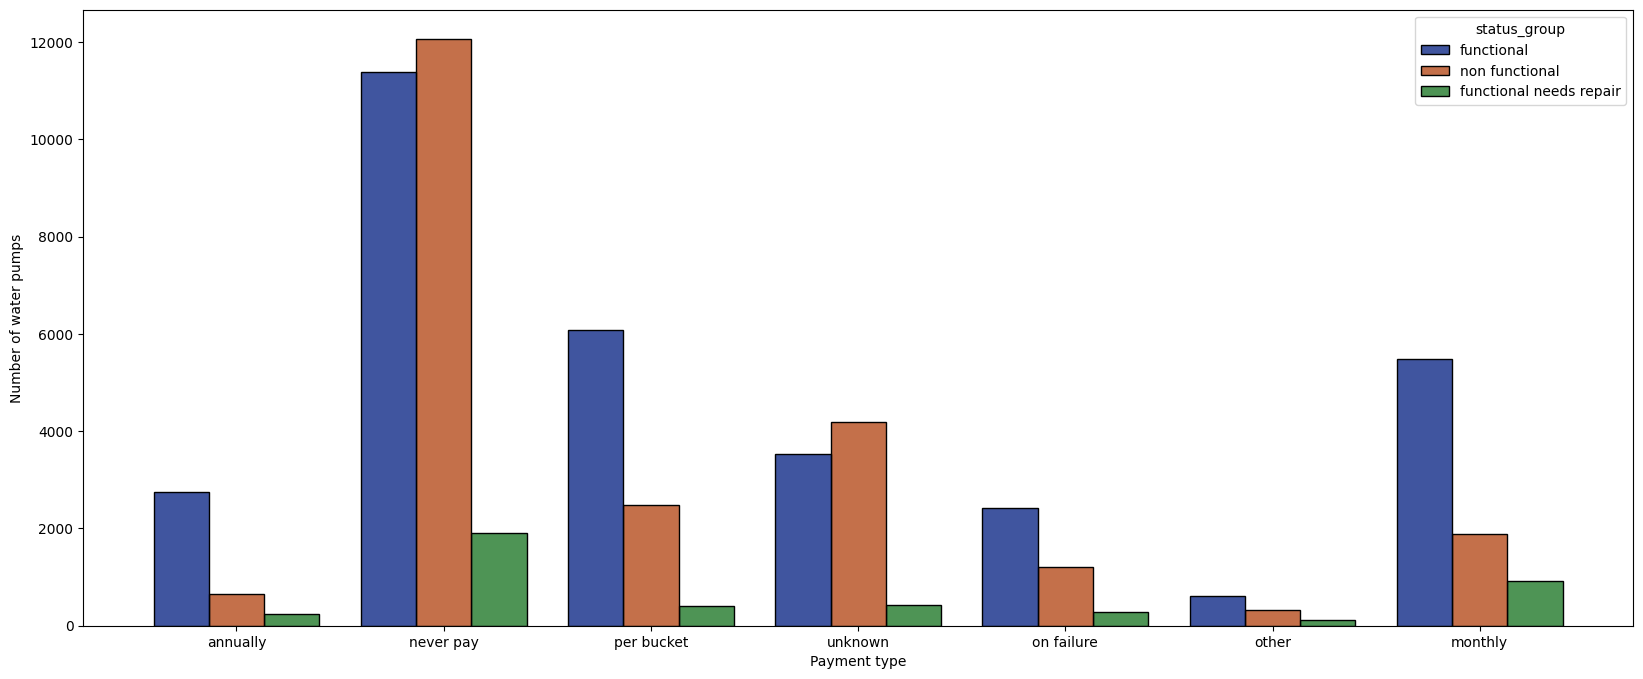

In [20]:
# Visualizing  payment type  effect on functionality status of the water pumps

fig, ax  = plt.subplots(figsize=(20,8))
sns.histplot(data=train_data, x="payment_type", hue="status_group", multiple="dodge",palette='dark', shrink=.8, ax=ax)
ax.set_xlabel("Payment type")
ax.set_ylabel("Number of water pumps");

# Observation
# Non functional pumps are are very high under Never pay category

<Axes: >

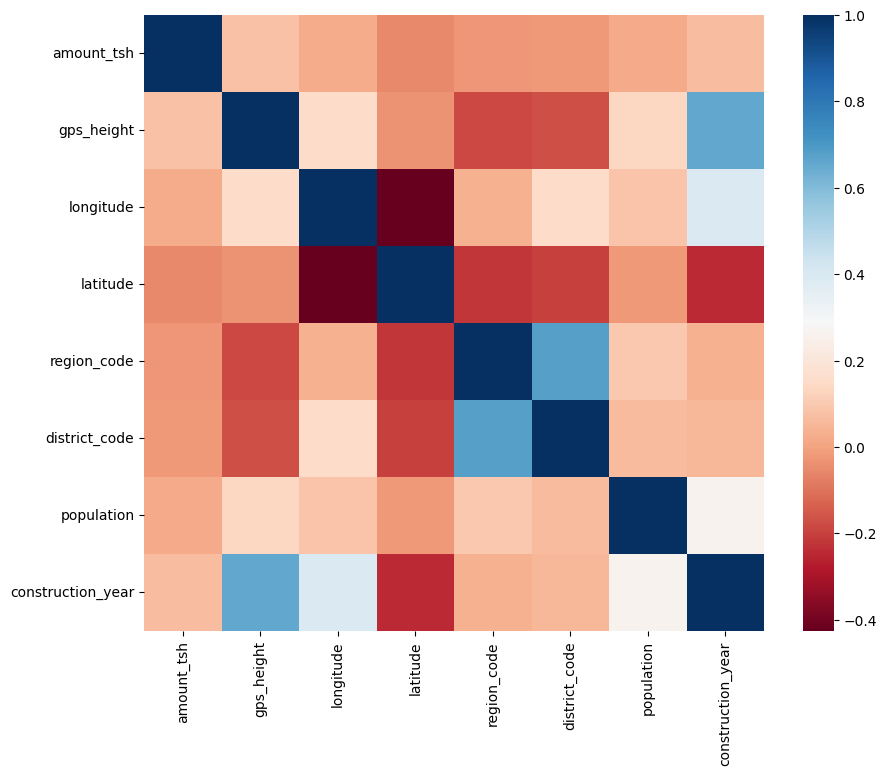

In [21]:
#Corerelation heat map for finding the 



f, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,cmap='RdBu')

#Observation

#gps_height and and Construction_year are slightly correlated
#longitude and latitude shows strong negative correlation (geographical coordinates vary inversely across regions in Tanzania)

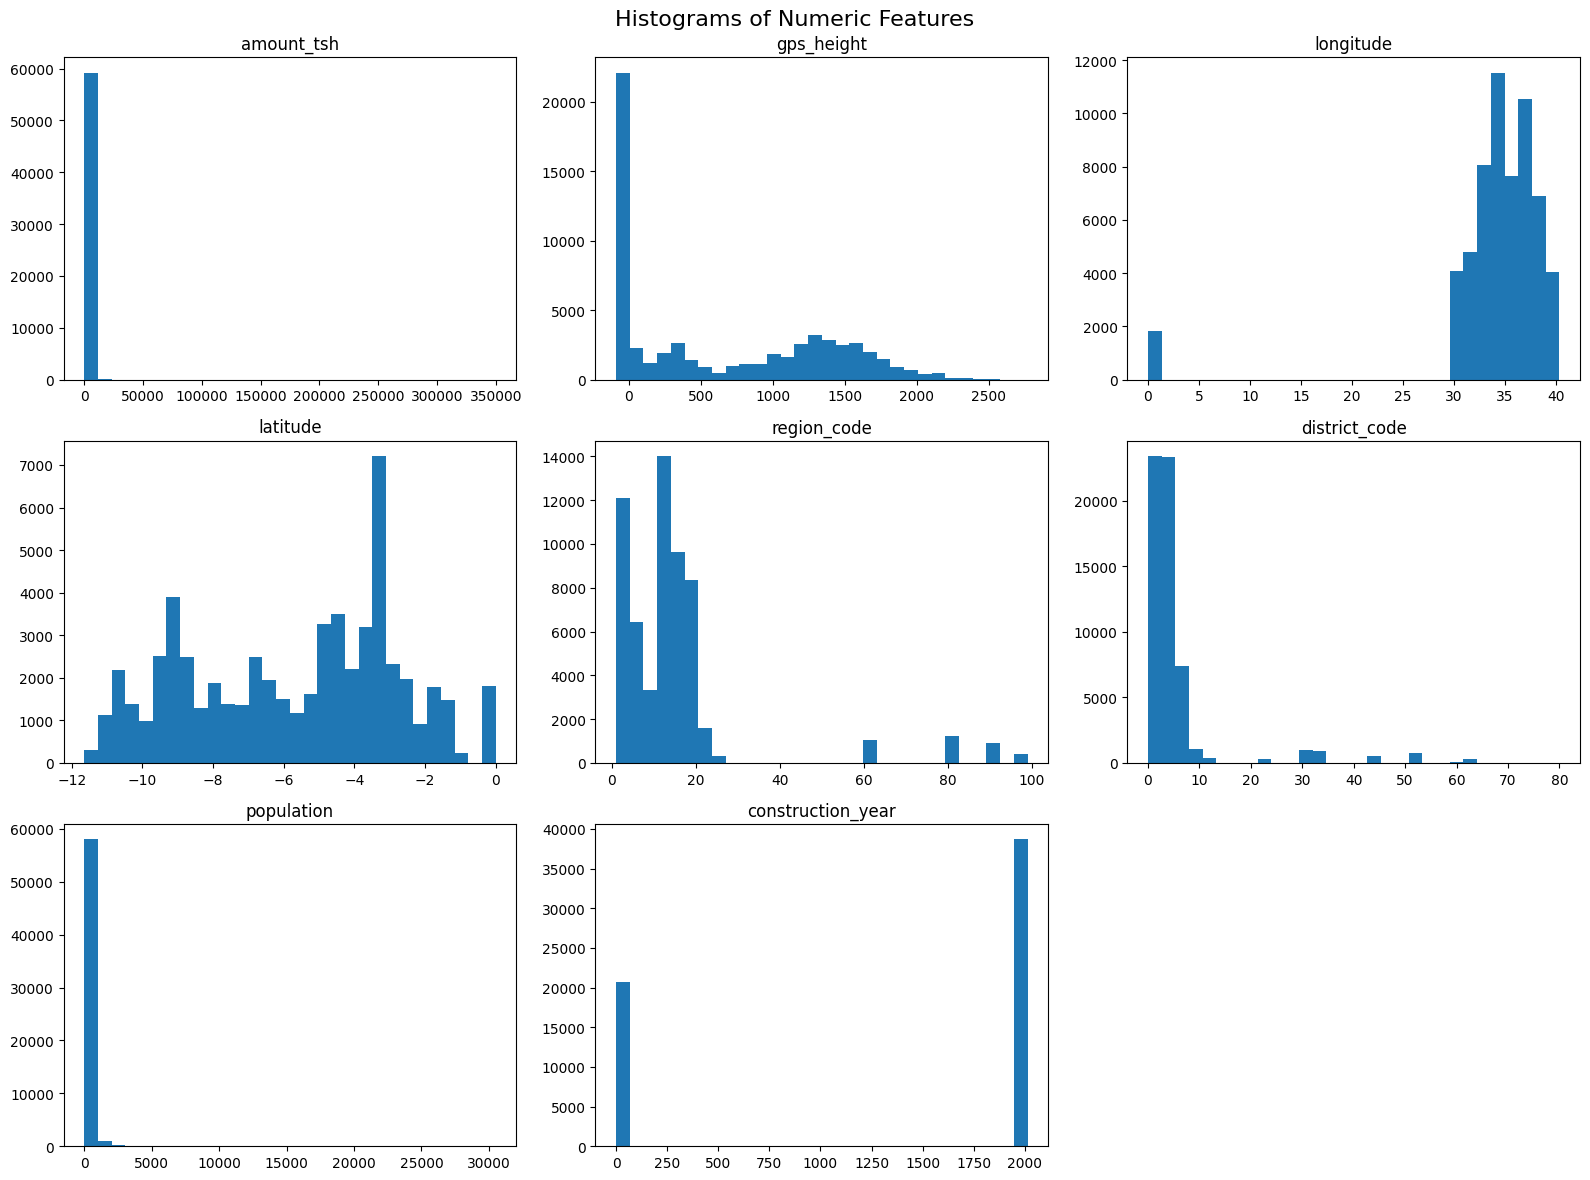

In [22]:
#numeric skew data distribution


numeric_columns = df.select_dtypes(include='number').columns


df[numeric_columns].hist(bins=30, figsize=(16, 12), grid=False)
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

#Observation
# amount_tsh  is right skewed and most of the values are 0
# We can do either log transform or clip extreme outliers
# population data is right skewed and most of the values are 0 as well
# Majority of the pumps are located in the area with small population ?

In [ ]:
#Handling outliers in numeric data